In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pathlib

In [3]:
!python --version

Python 3.13.15


In [4]:
print(tf.__version__)

2.20.0


In [5]:
import kagglehub

if 'path' not in globals():
    path = kagglehub.dataset_download("yasserh/auto-mpg-dataset")

print("Path to dataset files:", path)

100%|██████████| 6.31k/6.31k [00:00<00:00, 12.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/auto-mpg-dataset/versions/1


In [6]:
# importar el dataset
df = pd.read_csv(path + "/auto-mpg.csv")

df = df.drop(columns=["car name"])
df["horsepower"] = pd.to_numeric(df["horsepower"].replace("?", np.nan), errors="coerce")
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())
df = pd.get_dummies(df, columns=["origin"], prefix="origin", drop_first=True)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,False,False


In [7]:
# Definir X e y después de limpiar el dataframe
X = df.drop("mpg", axis=1)
y = df["mpg"]

In [8]:
# Validar celdas nulas de df
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin_2,0
origin_3,0


/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable h

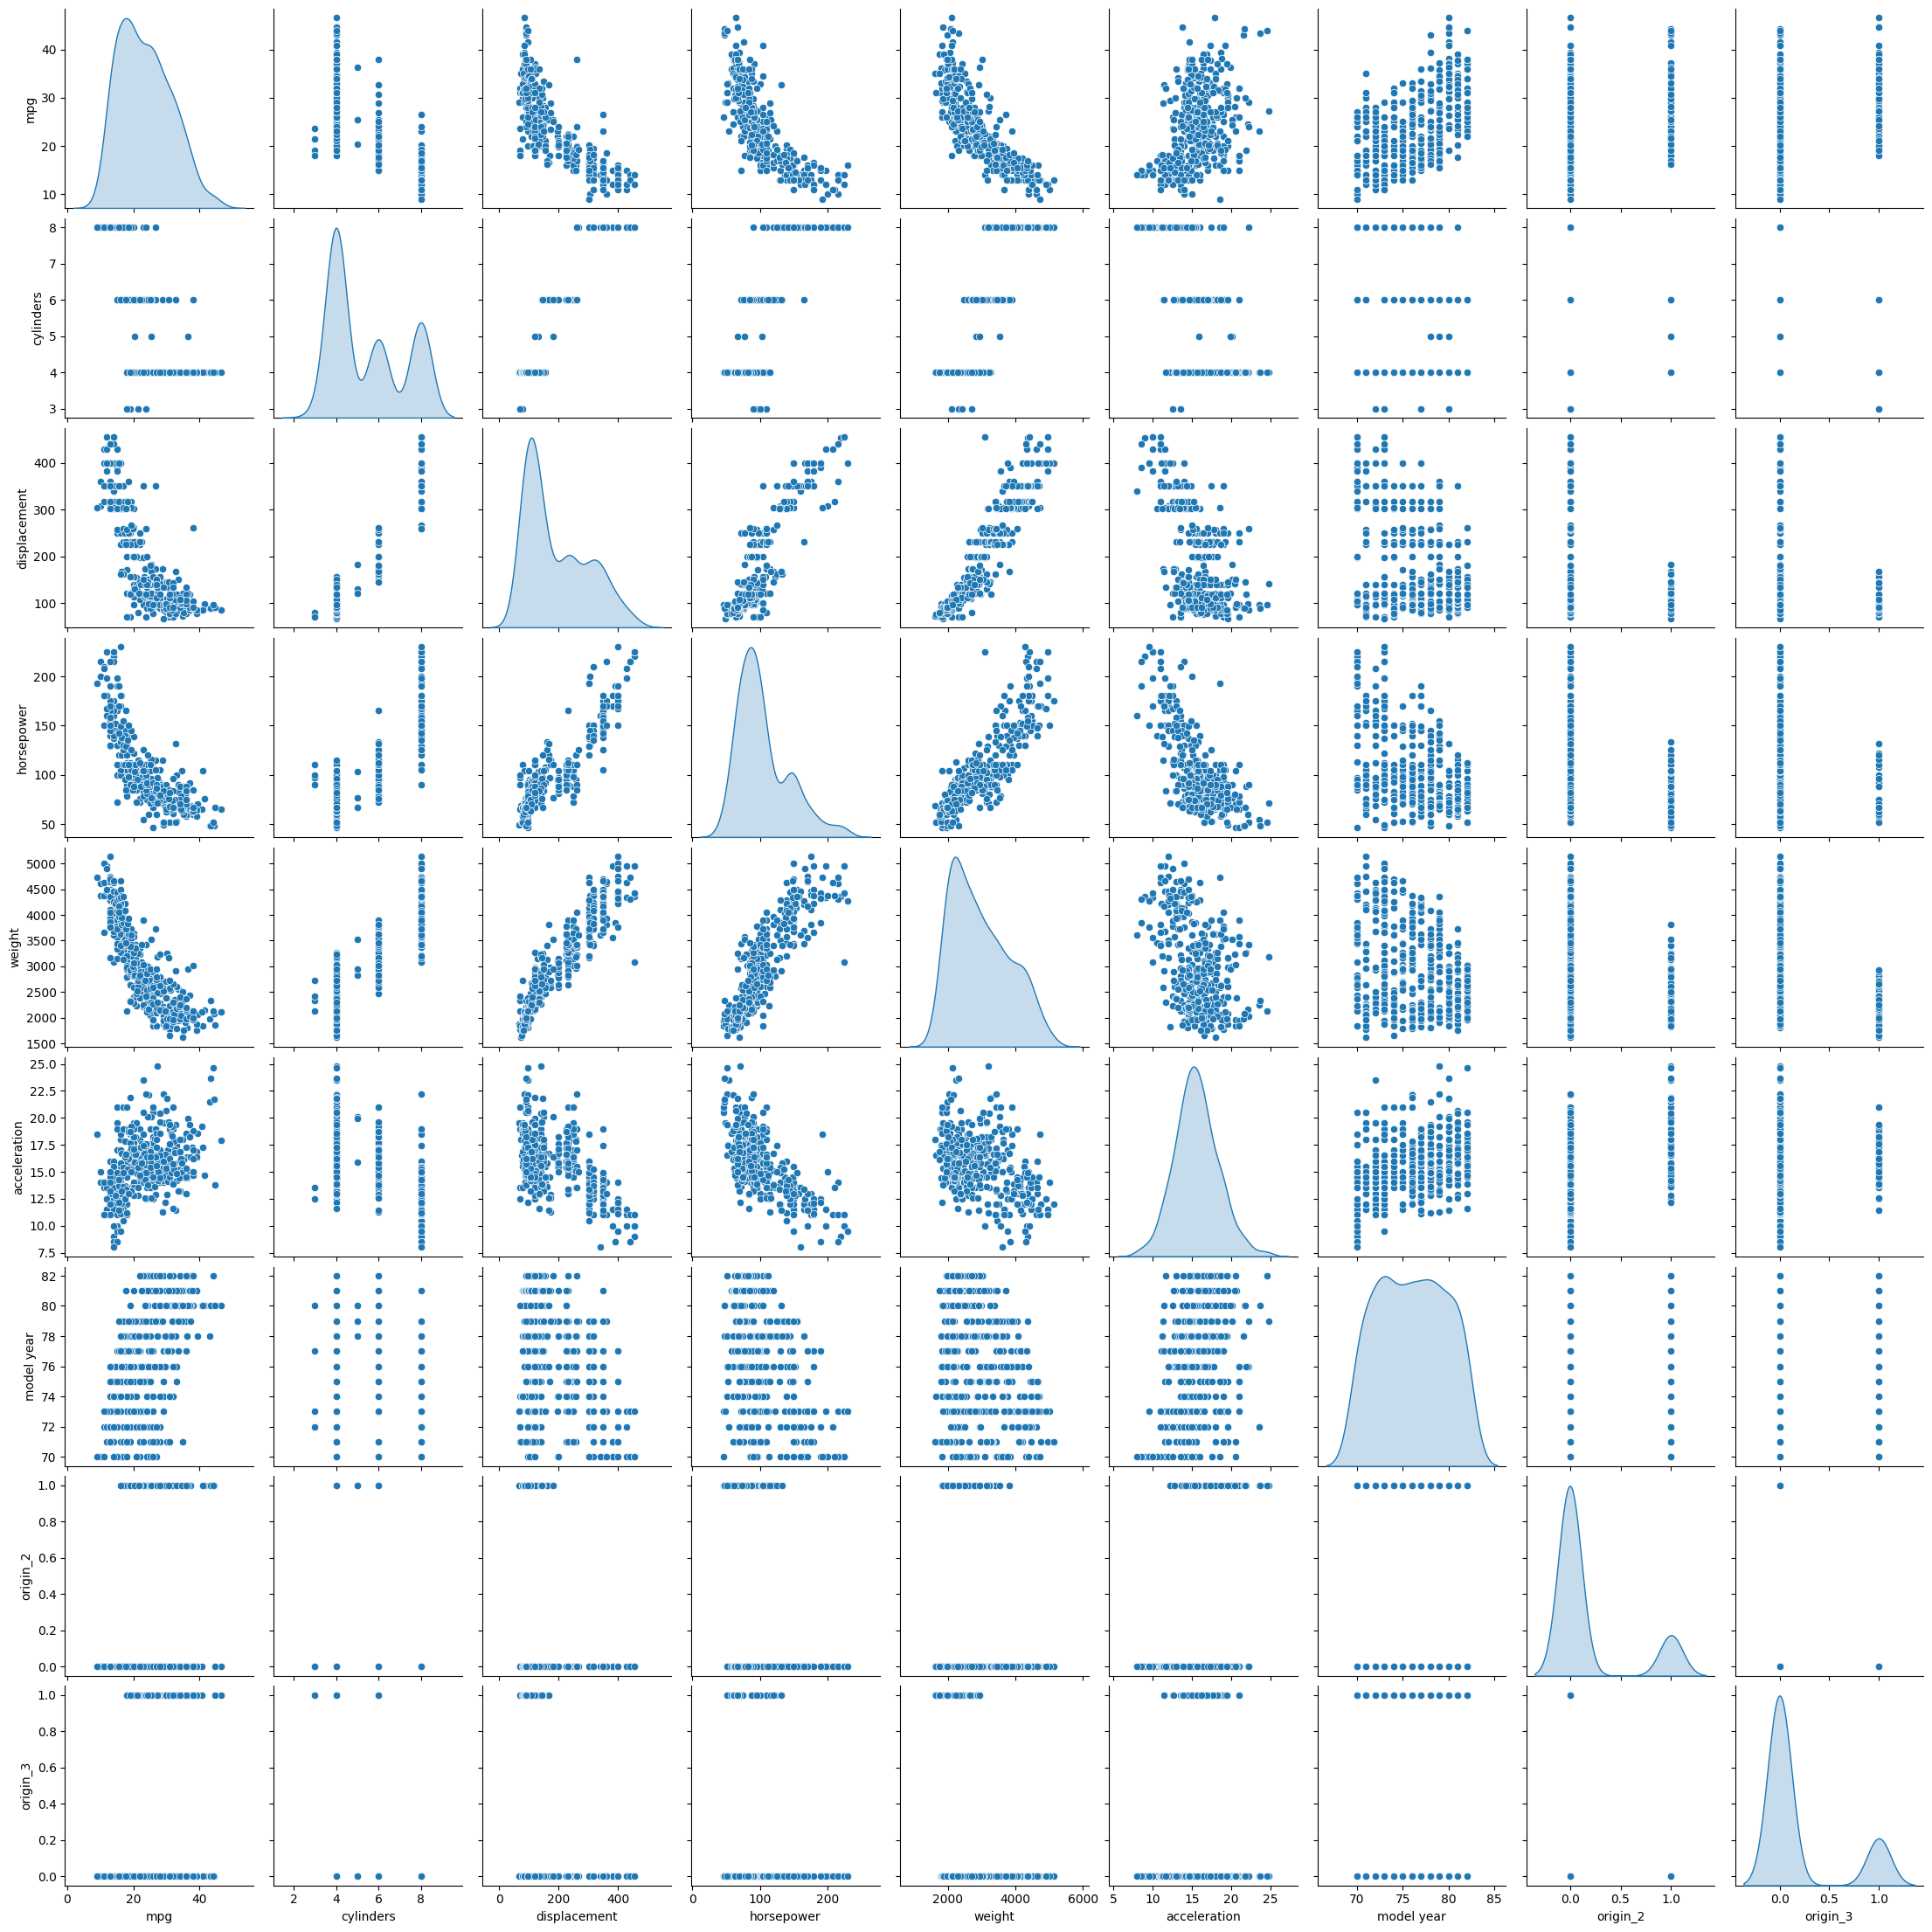

In [9]:
# Visualización rápida
sns.pairplot(df, diag_kind='kde', palette='Set2')
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin_2      398 non-null    bool   
 8   origin_3      398 non-null    bool   
dtypes: bool(2), float64(4), int64(3)
memory usage: 22.7 KB


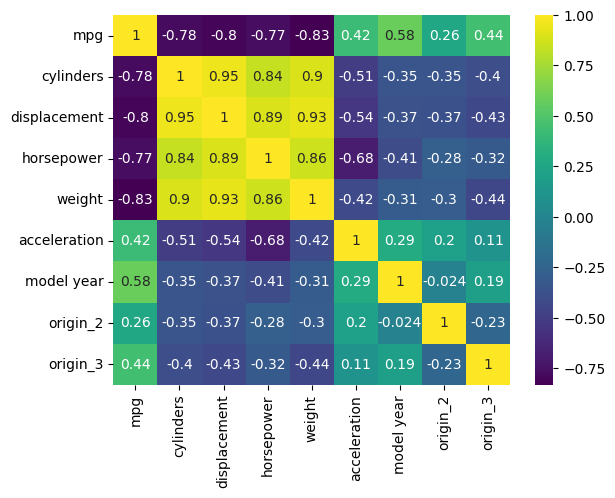

In [11]:
heatmap = sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.show()

In [12]:
# Dividir 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Normalizar usando StandardScaler sobre entrenamiento y aplicar luego a prueba
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = models.Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='linear')
])

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005),
    loss='mean_squared_error',
    metrics=['mae'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 564.9463 - mae: 22.3631 - val_loss: 468.1798 - val_mae: 20.3065
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 344.0003 - mae: 16.8125 - val_loss: 187.1595 - val_mae: 12.1336
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 103.9053 - mae: 8.5466 - val_loss: 42.0779 - val_mae: 5.0177
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 33.1432 - mae: 4.5768 - val_loss: 27.0509 - val_mae: 3.8758
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 23.6866 - mae: 3.8025 - val_loss: 21.7268 - val_mae: 3.5842
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.4711 - mae: 3.4488 - val_loss: 18.5294 - val_mae: 3.2799
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.7388 - mae: 3.1485 - val_loss: 16.9710 - val_mae: 3.1103
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14.0846 - mae: 2.8233 - val_loss: 17.3660 - val_mae: 3.1857
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/st

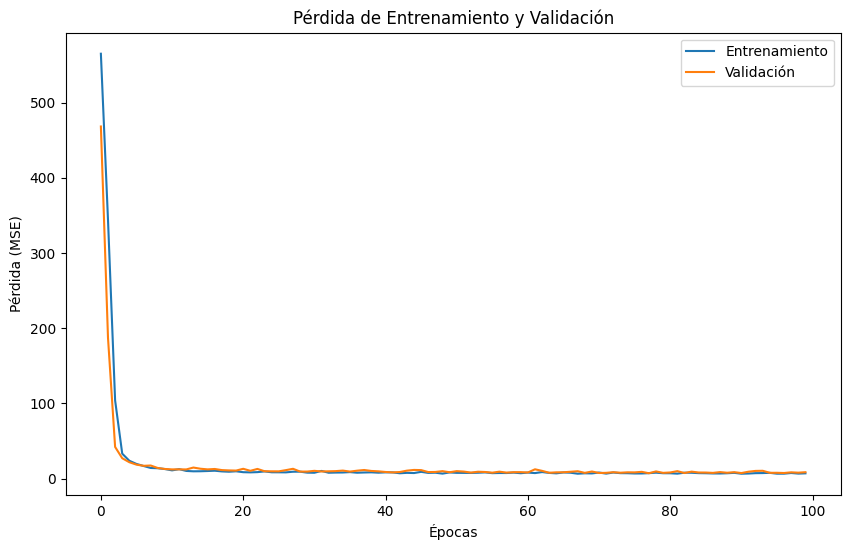

In [19]:
# Graficar las perdidas de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()


In [25]:
#Guardar el modelo .keras
model.save("modelo_gasolina.keras")

In [26]:
import os
print(os.getcwd())
print(os.path.abspath("modelo_gasolina.keras"))

/content
/content/modelo_gasolina.keras


In [22]:
# Predecir con los datos de prueba
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [23]:
# Calcular el error medio cuadratico y el error medio absoluto
mse = tf.keras.losses.MeanSquaredError()
mae = tf.keras.losses.MeanAbsoluteError()